In [1]:
# importation des librairies
import pandas as pd
import matplotlib.pyplot as plt


print("We beginning the history of our dataset")
print("Exploration")


We beginning the history of our dataset
Exploration


In [2]:
# télécharger le csv de l'hospitalisation suite à la COVOID le 31/03/2023
df = pd.read_csv("../data/covid-hospit-2023-03-31-18h01.csv", sep=";")

# voyons comment se présente notre po^pulation: aperçu de notre dataset
df_head = df.head()
print(df_head)

  dep  sexe        jour  hosp  rea  HospConv  SSR_USLD  autres  rad  dc
0  01     0  2020-03-18     2    0       NaN       NaN     NaN    1   0
1  01     1  2020-03-18     1    0       NaN       NaN     NaN    1   0
2  01     2  2020-03-18     1    0       NaN       NaN     NaN    0   0
3  02     0  2020-03-18    41   10       NaN       NaN     NaN   18  11
4  02     1  2020-03-18    19    4       NaN       NaN     NaN   11   6


In [32]:
# on va avoir un aperçu de la fin de notre df
df.tail(5)

,dep,sexe,jour,hosp,rea,HospConv,SSR_USLD,autres,rad,dc
338240,976,0,2023-03-31,0,0,0.0,0.0,0.0,1766,163
338241,976,1,2023-03-31,0,0,0.0,0.0,0.0,739,100
338242,976,2,2023-03-31,0,0,0.0,0.0,0.0,1002,61
338243,978,0,2023-03-31,0,0,0.0,0.0,0.0,0,0
338244,978,1,2023-03-31,0,0,0.0,0.0,0.0,0,0


On peut observer que nous avons 3 représentations du sexe:
0: hommes + femmes
1: hommes
2: femmes

Afin de pouvoir déduire que les valeurs de notre dataset sont groupés pour 0 certainement avec des données non détaillées et selon des situations, nous allons lors de l'analyse,
séparer notre df afin d'éviter des incohérences et des doubles comptages.


In [3]:
# nombre de lignes et de colonnes de notre BDD
df_col_ligne = df.shape

print(f"ce dataset est constitué de: \n {df_col_ligne[0]} lignes et \n {df_col_ligne[1]} colonnes")

ce dataset est constitué de: 
 338245 lignes et 
 10 colonnes


In [4]:
# liste de colonnes
df_col = df.columns
print(list(df_col))

['dep', 'sexe', 'jour', 'hosp', 'rea', 'HospConv', 'SSR_USLD', 'autres', 'rad', 'dc']


In [5]:
# afficher l'ensemble des informations sur notre dataset: 
# types de données, valeurs manquantes, nombres de lignes

df_info = df.info()

print(df_info)


<class 'pandas.DataFrame'>
RangeIndex: 338245 entries, 0 to 338244
Data columns (total 10 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   dep       338245 non-null  str    
 1   sexe      338245 non-null  int64  
 2   jour      338245 non-null  str    
 3   hosp      338245 non-null  int64  
 4   rea       338245 non-null  int64  
 5   HospConv  228140 non-null  float64
 6   SSR_USLD  228140 non-null  float64
 7   autres    228140 non-null  float64
 8   rad       338245 non-null  int64  
 9   dc        338245 non-null  int64  
dtypes: float64(3), int64(5), str(2)
memory usage: 25.8 MB
None


nous observons qu'il existe des valeurs manquantes dans certaines colonnes: HospConv, SSR_USLD, autres
nous avon 3 types de données object, float et int

In [6]:
# statistiques descriptives rapides
df.describe()

,sexe,hosp,rea,HospConv,SSR_USLD,autres,rad,dc
count,338245.000000,338245.000000,338245.000000,228140.000000,228140.000000,228140.000000,338245.000000,338245.000000
mean,0.996721,113.804733,13.363086,61.495625,35.983782,2.994867,2817.618895,534.741238
std,0.815822,166.746827,28.396802,83.826313,51.997225,5.827842,4173.613321,730.473523
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,23.000000,1.000000,15.000000,6.000000,0.000000,500.000000,105.000000
50%,1.000000,58.000000,4.000000,34.000000,18.000000,1.000000,1404.000000,278.000000
75%,2.000000,134.000000,13.000000,73.000000,44.000000,3.000000,3338.000000,653.000000
max,2.000000,3281.000000,855.000000,1115.000000,565.000000,170.000000,48210.000000,6463.000000


In [7]:
# vérifie les valeurs manquantes
df.isnull().sum().sort_values(ascending=False)

SSR_USLD    110105
HospConv    110105
autres      110105
dep              0
sexe             0
jour             0
rea              0
hosp             0
rad              0
dc               0
dtype: int64

In [8]:
# nous allons afficher les valeurs manquantes en pourcentage pour une meilleure visibilité
print(
    (round(df.isnull().sum()/len(df) *100,2
           ).sort_values(ascending=False)))

SSR_USLD    32.55
HospConv    32.55
autres      32.55
dep          0.00
sexe         0.00
jour         0.00
rea          0.00
hosp         0.00
rad          0.00
dc           0.00
dtype: float64


## nous allons essayer de comprendre pourquoi autant de données manquantes dans ces colonnes

In [9]:
df[df["HospConv"].isnull()].head()

,dep,sexe,jour,hosp,rea,HospConv,SSR_USLD,autres,rad,dc
0,01,0,2020-03-18,2,0,NaN,NaN,NaN,1,0
1,01,1,2020-03-18,1,0,NaN,NaN,NaN,1,0
2,01,2,2020-03-18,1,0,NaN,NaN,NaN,0,0
3,02,0,2020-03-18,41,10,NaN,NaN,NaN,18,11
4,02,1,2020-03-18,19,4,NaN,NaN,NaN,11,6


### nous allons essayer de comprendre les données manquantes car cela fait quand même 33%

In [10]:
# le premier jour où nous n'avons pas des données de ces colonnes: "HospConv", "SSR_USLD", "autres"
print(f' premier jour HospConv sans donnée: {df[df["HospConv"].isnull()]["jour"].min()}')
print(f' premier jour SSR_USLD sans donnée: {df[df["SSR_USLD"].isnull()]["jour"].min()}')
print(f' premier jour autres sans donnée: {df[df["autres"].isnull()]["jour"].min()}')



 premier jour HospConv sans donnée: 2020-03-18
 premier jour SSR_USLD sans donnée: 2020-03-18
 premier jour autres sans donnée: 2020-03-18


In [11]:
# le dernier jour où nous avons pas de données  de ces colonnes : "HospConv", "SSR_USLD", "autres"

print(f' dernier jour HospConv sans donnée: {df[df["HospConv"].isnull()]["jour"].max()}')
print(f' premier jour SSR_USLD sans donnée: {df[df["SSR_USLD"].isnull()]["jour"].max()}')
print(f' premier jour autres sans donnée: {df[df["autres"].isnull()]["jour"].max()}')

 dernier jour HospConv sans donnée: 2021-03-13
 premier jour SSR_USLD sans donnée: 2021-03-13
 premier jour autres sans donnée: 2021-03-13


In [12]:
# le premier jour où les données apparaissent avec ces colonnes: "HospConv", "SSR_USLD", "autres"


print(f' premier jour HospConv avec données : {df[df["HospConv"].notnull()]["jour"].min()}')
print(f' premier jour SSR_USLD avec données : {df[df["SSR_USLD"].notnull()]["jour"].min()}')
print(f' premier jour autres avec données   : {df[df["autres"].notnull()]["jour"].min()}')

 premier jour HospConv avec données : 2021-03-14
 premier jour SSR_USLD avec données : 2021-03-14
 premier jour autres avec données   : 2021-03-14


In [13]:
# le dernier jour où nous avons de données  ces colonnes : "HospConv", "SSR_USLD", "autres"
print(f' dernier jour HospConv avec données : {df[df["HospConv"].notnull()]["jour"].max()}')
print(f' premier jour SSR_USLD avec données : {df[df["SSR_USLD"].notnull()]["jour"].max()}')
print(f' premier jour autres avec données   : {df[df["autres"].notnull()]["jour"].max()}')

 dernier jour HospConv avec données : 2023-03-31
 premier jour SSR_USLD avec données : 2023-03-31
 premier jour autres avec données   : 2023-03-31


""" A partir de ces observations, nous pouvons en déduire :
les données des colonnes 
HospConv
SSR_USLD
autres
n'étaient pas collectées au début de la pandémie.

Donc les valeurs manquantes ne sont probablement pas des erreurs mais des données inexistantes.
on pourrait envisager un remplissage pour éviter un biais"""

In [14]:
# le nombre de départements représentés dans notre dataset
nbr_dep= df["dep"].nunique()
print(f" Les données de notre DataFrame couvrent {nbr_dep} départements Français.")

 Les données de notre DataFrame couvrent 102 départements Français.


Pourquoi 102 départements? 
Le jeu de données couvre 102 codes départementaux. Ce nombre est légèrement supérieur aux 101 départements français habituellement recensés, ce qui suggère la présence d'un code administratif spécifique ou d'une collectivité supplémentaire. Une analyse complémentaire des codes départementaux permettra d'identifier cette particularité.

In [15]:
# aperçu des différents départements
print(sorted(df.dep.unique()))


['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '21', '22', '23', '24', '25', '26', '27', '28', '29', '2A', '2B', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '971', '972', '973', '974', '976', '978']


On peut voir que les 102 sont dûs à la présence des départements 2A et 2B fesant référence à la Corse-du-Sud et la Haute-Corse respectivement.

In [16]:
#La période que couvre l'hospitalisation de notre dataFrame

print(df.jour.unique())
print(f"le 1er jour est: {df.jour.min()}")
print(f"le dernier est: {df.jour.max()}")


<StringArray>
['2020-03-18', '2020-03-19', '2020-03-20', '2020-03-21', '2020-03-22',
 '2020-03-23', '2020-03-24', '2020-03-25', '2020-03-26', '2020-03-27',
 ...
 '2023-03-22', '2023-03-23', '2023-03-24', '2023-03-25', '2023-03-26',
 '2023-03-27', '2023-03-28', '2023-03-29', '2023-03-30', '2023-03-31']
Length: 1109, dtype: str
le 1er jour est: 2020-03-18
le dernier est: 2023-03-31


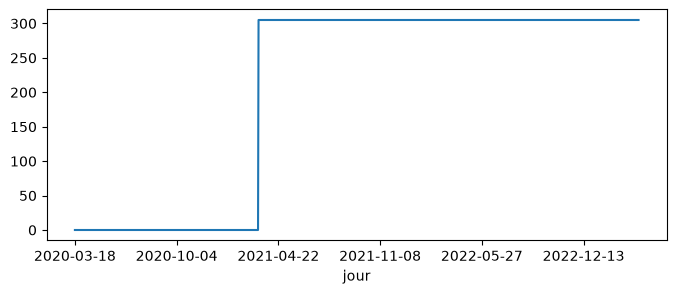

In [17]:
# nous allons avoir un aperçu graphique du contenu des colonnes contenant des NAN
df.groupby("jour")["HospConv"].count().plot(figsize=(8,3))
plt.show()

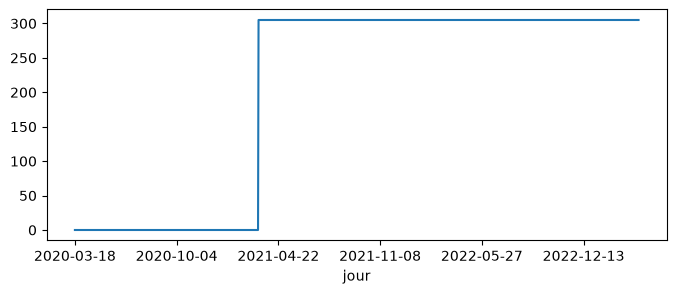

In [18]:
df.groupby("jour")["SSR_USLD"].count().plot(figsize=(8,3))
plt.show()

<Axes: xlabel='jour'>

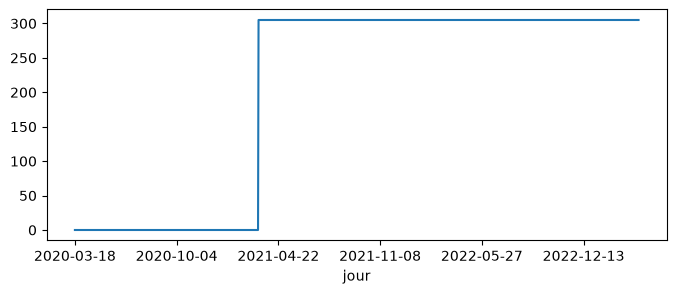

In [19]:
df.groupby("jour")["autres"].count().plot(figsize=(8,3))

In [20]:
df.head()

,dep,sexe,jour,hosp,rea,HospConv,SSR_USLD,autres,rad,dc
0,01,0,2020-03-18,2,0,NaN,NaN,NaN,1,0
1,01,1,2020-03-18,1,0,NaN,NaN,NaN,1,0
2,01,2,2020-03-18,1,0,NaN,NaN,NaN,0,0
3,02,0,2020-03-18,41,10,NaN,NaN,NaN,18,11
4,02,1,2020-03-18,19,4,NaN,NaN,NaN,11,6
